In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [30]:
print("\nProblem Statement:")
print("Predict whether an individual seeks mental health treatment based on available features.")   


Problem Statement:
Predict whether an individual seeks mental health treatment based on available features.


In [31]:
df= pd.read_csv('Mental Health Dataset.csv')

In [32]:
df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [33]:
# Fill categorical with mode, numerical with median
for col in df.columns:
    if df[col].dtype == "object" or df[col].dtype == "str":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

C:\Users\mahap\AppData\Local\Temp\ipykernel_12528\905174503.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mode()[0], inplace=True)


In [34]:
#performing label encoding at once on the required columns

le = LabelEncoder()

cols = ["Gender", "self_employed", "family_history", "treatment", "Growing_Stress", "Changes_Habits", "Mental_Health_History", "Coping_Struggles", "Work_Interest", "Social_Weakness"]  # your columns

for col in cols:
    df[col] = le.fit_transform(df[col])

In [35]:
#Occupation col
df = pd.get_dummies(df, columns=["Occupation"], drop_first=True, dtype= int)

In [36]:
#Days_Indoors col
df["Days_Indoors"] = df["Days_Indoors"].str.strip()

In [37]:
encoder = OrdinalEncoder(categories=[[
    "More than 2 months",
    "31-60 days",
    "15-30 days",
    "1-14 days",
    "Go out Every day"
]])

df["Days_Indoors"] = encoder.fit_transform(df[["Days_Indoors"]])

In [38]:
#performing ordinal on columns with orders like low, med, high or yes, no, maybe
#performing ordinal encoding- to maintain the order as it is
#1. Mood_Swings col
moodencode = OrdinalEncoder(categories=[[
    "Low",
    "Medium",
    "High"
]])

df["Mood_Swings"] = moodencode.fit_transform(df[["Mood_Swings"]])

In [39]:
#2. mental_health_interview col
mentalencode = OrdinalEncoder(categories=[[
    "No",
    "Yes",
    "Maybe"
]])

df["mental_health_interview"] = mentalencode.fit_transform(df[["mental_health_interview"]])

In [40]:
#3. care_options
careencode = OrdinalEncoder(categories=[[
    "No",
    "Yes",
    "Not sure"
]])

df["care_options"] = careencode.fit_transform(df[["care_options"]])

In [41]:
#converting the datatype
datacol= ['Days_Indoors', 'care_options', 'mental_health_interview', 'Mood_Swings']
for col in datacol:
    df[col] = df[col].astype(int)

In [42]:
#checking the final data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Timestamp                292364 non-null  str  
 1   Gender                   292364 non-null  int64
 2   Country                  292364 non-null  str  
 3   self_employed            292364 non-null  int64
 4   family_history           292364 non-null  int64
 5   treatment                292364 non-null  int64
 6   Days_Indoors             292364 non-null  int64
 7   Growing_Stress           292364 non-null  int64
 8   Changes_Habits           292364 non-null  int64
 9   Mental_Health_History    292364 non-null  int64
 10  Mood_Swings              292364 non-null  int64
 11  Coping_Struggles         292364 non-null  int64
 12  Work_Interest            292364 non-null  int64
 13  Social_Weakness          292364 non-null  int64
 14  mental_health_interview  292364 non-null  int64

In [43]:
df.head()

,Timestamp,Gender,Country,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Occupation_Corporate,Occupation_Housewife,Occupation_Others,Occupation_Student
0,8/27/2014 11:29,0,United States,2,0,1,3,2,1,2,1,0,1,2,0,2,1,0,0,0
1,8/27/2014 11:31,0,United States,2,1,1,3,2,1,2,1,0,1,2,0,0,1,0,0,0
2,8/27/2014 11:32,0,United States,2,1,1,3,2,1,2,1,0,1,2,0,1,1,0,0,0
3,8/27/2014 11:37,0,United States,0,1,1,3,2,1,2,1,0,1,2,2,1,1,0,0,0
4,8/27/2014 11:43,0,United States,0,1,1,3,2,1,2,1,0,1,2,0,1,1,0,0,0


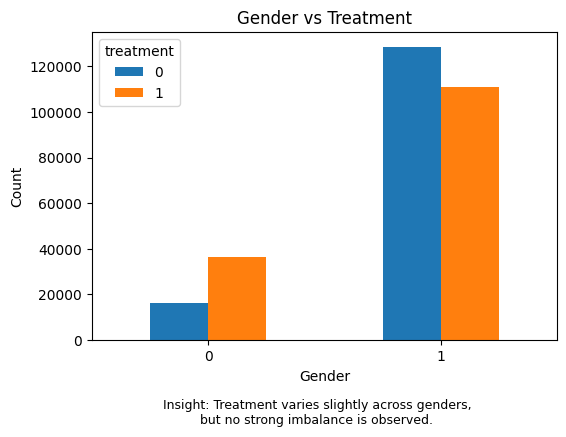

In [44]:
#insight draw using matplotlib
ct = pd.crosstab(df["Gender"], df["treatment"])

ct.plot(kind="bar", figsize=(6,4))

plt.title("Gender vs Treatment")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)

#Insight text
plt.figtext(
    0.5, -0.1,
    "Insight: Treatment varies slightly across genders,\nbut no strong imbalance is observed.",
    ha="center",
    fontsize=9
)

plt.show()

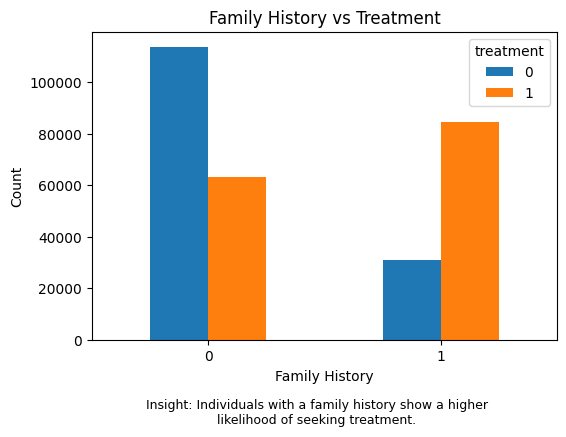

In [45]:
#insight 2
ct1 = pd.crosstab(df["family_history"], df["treatment"])

ax= ct1.plot(kind="bar", figsize=(6,4))

plt.title("Family History vs Treatment")
plt.xlabel("Family History")
plt.ylabel("Count")
plt.xticks(rotation=0)

# 👉 Insight text
plt.figtext(
    0.5, -0.1,
    "Insight: Individuals with a family history show a higher\nlikelihood of seeking treatment.",
    ha="center",
    fontsize=9
)

plt.show()

In [46]:
#saving the cleaned data
df.to_csv('cleaned_df.csv')

In [47]:
df

,Timestamp,Gender,Country,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,Occupation_Corporate,Occupation_Housewife,Occupation_Others,Occupation_Student
0,8/27/2014 11:29,0,United States,2,0,1,3,2,1,2,1,0,1,2,0,2,1,0,0,0
1,8/27/2014 11:31,0,United States,2,1,1,3,2,1,2,1,0,1,2,0,0,1,0,0,0
2,8/27/2014 11:32,0,United States,2,1,1,3,2,1,2,1,0,1,2,0,1,1,0,0,0
3,8/27/2014 11:37,0,United States,0,1,1,3,2,1,2,1,0,1,2,2,1,1,0,0,0
4,8/27/2014 11:43,0,United States,0,1,1,3,2,1,2,1,0,1,2,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292359,7/27/2015 23:25,1,United States,1,1,1,2,1,0,1,0,1,1,0,2,2,0,0,0,0
292360,8/17/2015 9:38,1,South Africa,0,1,1,2,1,0,1,0,1,1,0,0,1,0,0,0,0
292361,8/25/2015 19:59,1,United States,0,1,0,2,1,0,1,0,1,1,0,0,0,0,0,0,0
292362,9/26/2015 1:07,1,United States,0,1,1,2,1,0,1,0,1,1,0,0,1,0,0,0,0


In [48]:
#input and output decision
X= df.drop(['Timestamp', 'Country', 'treatment'], axis=1)
y= df.treatment


In [49]:
y.value_counts()

treatment
1    147606
0    144758
Name: count, dtype: int64

In [50]:
#splitting the data
Xtrain, Xtest, ytrain, ytest= train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
#Feature scaling
scalar= StandardScaler()
Xtrain_scaled = scalar.fit_transform(Xtrain)
Xtest_scaled = scalar.transform(Xtest)

In [52]:
#model selection
best_model = None
best_model_name = ""
best_score = 0  

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=10, class_weight='balanced', random_state=42),
}


results = []

for name, model in models.items():
    
    if name == "Logistic Regression":
        model.fit(Xtrain_scaled, ytrain)
        y_pred = model.predict(Xtest_scaled)
    
    else:
        model.fit(Xtrain, ytrain)
        y_pred = model.predict(Xtest)
        
    
    acc = accuracy_score(ytest, y_pred)
    prec = precision_score(ytest, y_pred, zero_division=0)
    rec = recall_score(ytest, y_pred, zero_division=0)
    
    results.append([name, acc, prec, rec])

In [53]:
if acc > best_score:
        best_score = acc
        best_model = model
        best_model_name = name

print("\nBest Model:", best_model_name)
print("Best Accuracy:", best_score)


Best Model: Random Forest
Best Accuracy: 0.7199562191096746


In [54]:
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "features.joblib")

['features.joblib']

In [55]:
joblib.dump(best_model, f"{best_model_name}_model.joblib")

print(f"{best_model_name} saved successfully!")

Random Forest saved successfully!
